#  Car Price Prediction – Machine Learning Examination Project

**Objective:**
Predict a car’s **selling price** based on its key characteristics using **supervised machine learning** techniques.
The goal is to build a data-driven model that estimates resale prices accurately based on real-world car attributes such as year, mileage, fuel type, and transmission.

---

###  Dataset Source
The dataset used in this project was collected from **Kaggle’s “Car Price Prediction” dataset**, which contains records of used cars sold in India.
It includes essential details such as:
- `Car_Name` – brand or model name
- `Year` – manufacturing year
- `Selling_Price` – resale price (target variable)
- `Present_Price` – current showroom price when new
- `Kms_Driven` – total kilometers driven
- `Fuel_Type`, `Seller_Type`, `Transmission`, `Owner` – categorical and ownership details

This dataset is clean, balanced, and suitable for regression modeling.

---

###  What This Model Does
1. **Data Exploration (EDA):**
   Understand feature distributions, correlations, and how each factor (e.g., year or mileage) affects the selling price.

2. **Data Preprocessing:**
   - Scale numerical columns (e.g., Year, Kms_Driven).
   - Encode categorical columns (e.g., Fuel_Type, Transmission).
   - Prepare a machine-learning–ready feature matrix.

3. **Model Training:**
   Train multiple regression algorithms —
   **Linear Regression**, **Random Forest**, and **Gradient Boosting** — to predict car prices.

4. **Model Evaluation:**
   Compare models using **MAE**, **RMSE**, and **R²** metrics to identify the most accurate performer.

5. **Model Optimization & Saving:**
   - Select the best model (lowest RMSE).
   - Save it as a `.pkl` file along with its feature schema for future prediction via an API.

---

###  Workflow Summary

| Step | Description |
|------|--------------|
| **1. EDA** | Explore data distribution and relationships between variables. |
| **2. Preprocessing** | Prepare numerical and categorical data for modeling. |
| **3. Modeling** | Train multiple regression models. |
| **4. Evaluation** | Compare models and interpret results. |
| **5. Optimization** | Select, tune, and save the best-performing model. |

---

###  Expected Outcome
By the end of this project, we will have a **trained, validated, and exportable regression model** capable of predicting used car prices accurately — a foundation for real-world applications such as online car resale valuation tools or dealership pricing systems.#  Car Price Prediction – Machine Learning Examination Project

**Objective:**
Predict a car’s **selling price** based on its features using supervised machine learning.

**Workflow:**
1. **EDA** – Explore data distribution and feature relationships.
2. **Baseline Models** – Train multiple regression models (Linear, Random Forest, Gradient Boosting).
3. **Model Optimization** – Compare and select the best model based on RMSE and R².
4. **Evidence** – Visualize performance and interpret key results.
5. **Why** – Justify model choice and discuss predictive accuracy.

## A. Setup & load

In [2]:
# A. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from IPython.display import display
import seaborn as sns
# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from joblib import dump

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

# --- Path Reading ---
# In notebooks, __file__ doesn't exist, so fall back to cwd()
ROOT = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
csv_path = ROOT / "car_prediction_data.csv"
print(csv_path, csv_path.exists())

df = pd.read_csv(csv_path)
df.head()

/Users/sawratan/PycharmProjects/car_price_prediction_ML_project/ backend/car_prediction_data.csv True


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Explain:

    1.	Imports the libraries we’ll use:
	•	pandas/numpy for data handling,
	•	matplotlib for future plots,
	•	scikit-learn modules for later preprocessing, modeling, and evaluation.

	2.	Sets display options so pandas shows all columns when we inspect data.
	3.	Fixes a random seed (RANDOM_STATE=42) so any operation that involves randomness
	        (like a train/test split) is repeatable.
	4.	Loads the dataset from car_prediction_data.csv into a DataFrame named df.
	5.	Shows df.head() so we can quickly verify that the file path is correct and check the
	        first rows, column names, and data types. If this works, we know the dataset
	        is in place and ready for EDA (Exploratory Data Analysis).

## B. Quick data audit

In [3]:
df.info()                    # show column names, data types, and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Data Info (df.info())

Purpose:
This shows a quick summary of your dataset — all column names, their data types (e.g., int64, float64, object), and how many non-missing values each has.

Interpretation:
	•	There are 301 rows (cars) and 9 columns.
	•	No column has missing values (all show 301 non-null).
	•	Some columns are numerical (int64, float64) and others are categorical (object), which we’ll treat differently in preprocessing.


In [4]:
df.describe(include="all").T                 # summary stats for both numeric and categorical data

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


Summary Statistics (df.describe(include=“all”))

Purpose:
Gives overall statistics (mean, min, max, unique counts) for both numbers and text columns.

Interpretation:
	•	The average car year is around 2014.
	•	The average selling price is about 4.66 lakh (or 466,000).
	•	Fuel_Type has 3 unique categories (Petrol, Diesel, CNG).
	•	Seller_Type has 2 categories: Dealer and Individual.
	•	Transmission has 2 types: Manual and Automatic.

These numbers confirm that the dataset is clean and covers multiple types of cars.


In [5]:
df.isna().sum().sort_values(ascending=False)                       # check missing values in each column

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Missing Values Check (df.isna().sum())

Purpose:
To check if any column has missing (NaN) values that need to be cleaned.

Interpretation:
All columns have 0 missing values, so the dataset is complete and ready for analysis.

## C. Exploratory Data Analysis (EDA)

Adjust the column names below to match your dataset (e.g., `Selling_Price`, `Year`, `Kms_Driven`, `Fuel_Type`, `Seller_Type`, `Transmission`, `Owner`, `Car_Name`).

### Purpose of EDA
Exploratory Data Analysis (EDA) helps us understand the structure and quality of the dataset before building a model.
In this step, we:
- Check data types and missing values.
- Review summary statistics for both numeric and categorical columns.
- Explore relationships between features and the target (`Selling_Price`).
- Use visualizations (histograms, scatter plots, boxplots, and heatmaps) to detect trends, outliers, and correlations.

The goal is to confirm that our dataset is clean, balanced, and suitable for regression modeling — and to identify which variables most strongly influence car prices.

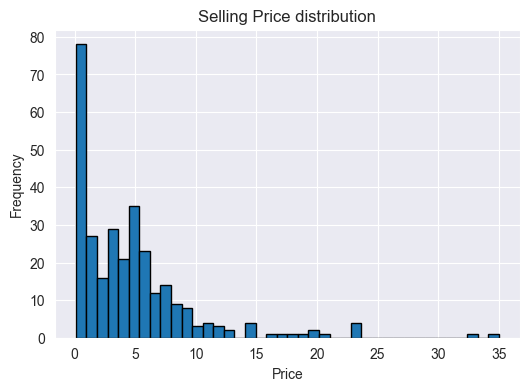

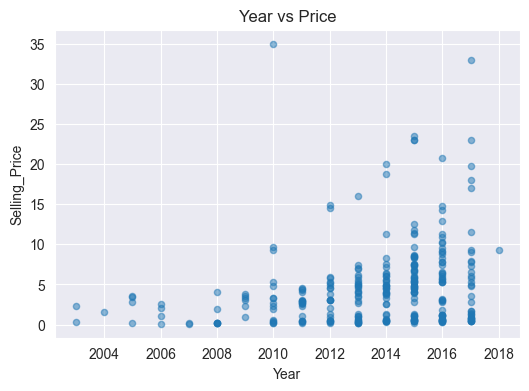

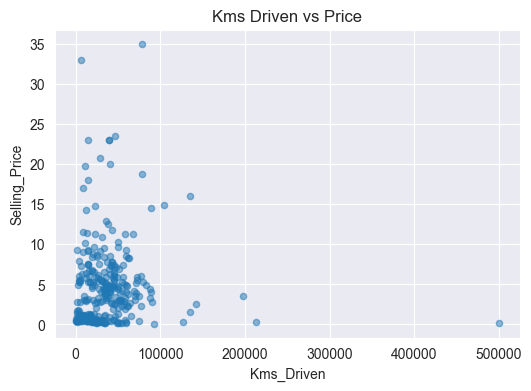

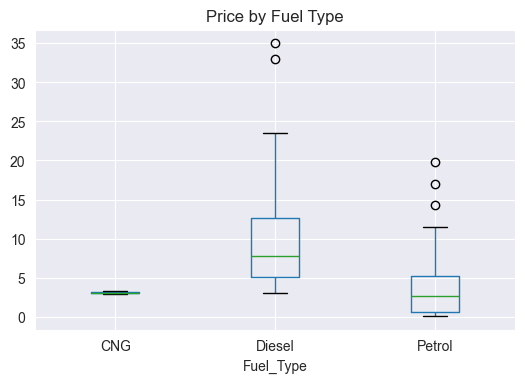

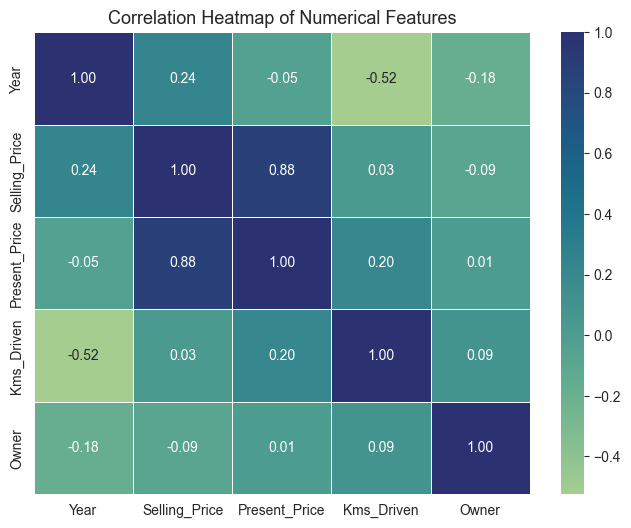

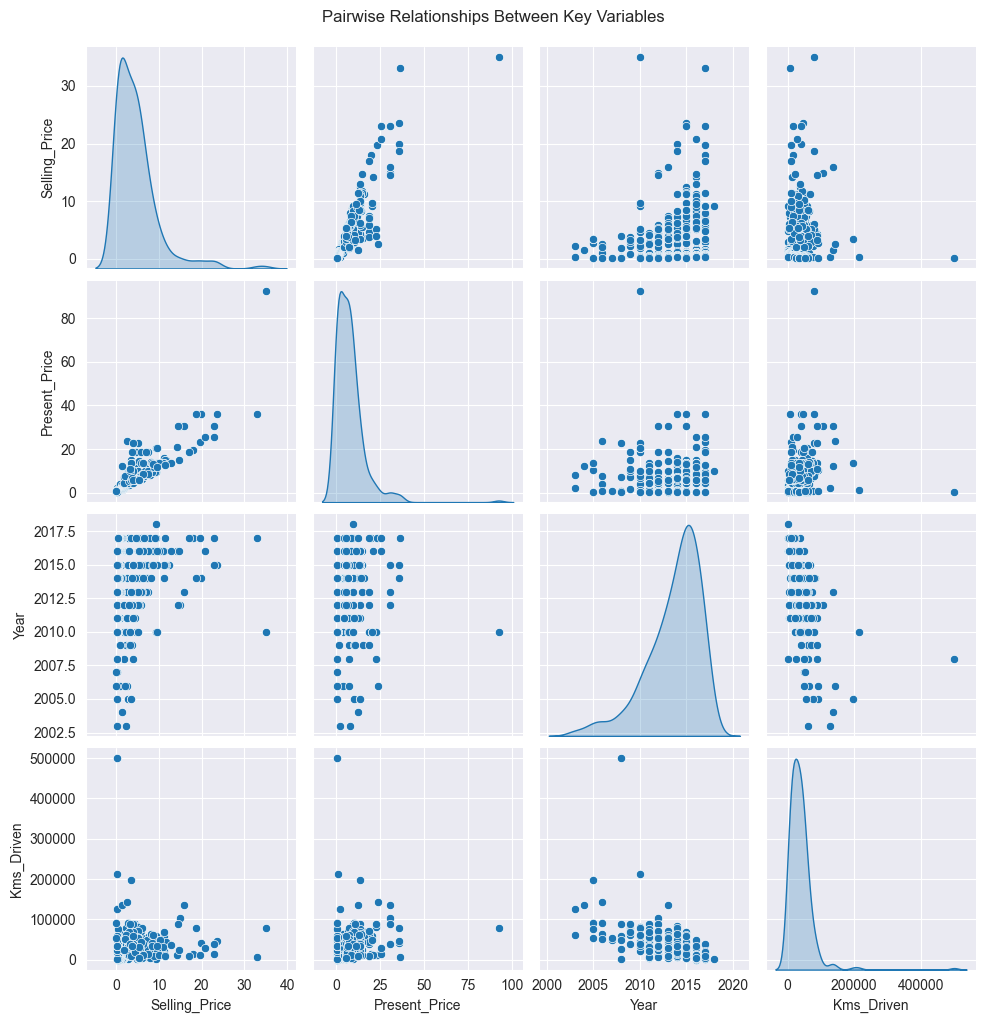

In [6]:
target_col = "Selling_Price"   # correct case

# 1) Target distribution
df[target_col].plot(kind="hist", bins=40, figsize=(6,4), edgecolor="black")
plt.title("Selling Price distribution")
plt.xlabel("Price")
plt.show()

# 2) Scatter: Year vs Price
if "Year" in df.columns:
    df.plot(kind="scatter", x="Year", y=target_col, alpha=0.5, figsize=(6,4))
    plt.title("Year vs Price")
    plt.show()

# 3) Scatter: Kms Driven vs Price
if "Kms_Driven" in df.columns:
    df.plot(kind="scatter", x="Kms_Driven", y=target_col, alpha=0.5, figsize=(6,4))
    plt.title("Kms Driven vs Price")
    plt.show()

# 4) Boxplot: Price by Fuel Type
if "Fuel_Type" in df.columns:
    df.boxplot(column=target_col, by="Fuel_Type", figsize=(6,4))
    plt.title("Price by Fuel Type")
    plt.suptitle("")   # removes automatic suptitle
    plt.show()



    # ==== Correlation Heatmap for Numeric Features ====
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="crest", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=13)
plt.show()

# ==== Pairplot for Key Features ====
key_cols = ["Selling_Price", "Present_Price", "Year", "Kms_Driven"]
sns.pairplot(df[key_cols], diag_kind="kde")
plt.suptitle("Pairwise Relationships Between Key Variables", y=1.02)
plt.show()

### Selling Price Distribution (Histogram)

Purpose:
Histogram shows how car selling prices are spread or distributed across the dataset — useful for spotting skewness or outliers.

Interpretation:

	•	Most cars sell for a low price (0–10 lakhs).
	•	Only a few outliers exist where prices go above 25–30 lakhs.
	•	The shape is right-skewed, meaning most cars are cheaper, and a few are luxury/expensive ones.

### Year vs Price (Scatter plot)

Purpose:
Visualize how the car’s manufacturing year affects its selling price — newer cars generally have higher prices.

Interpretation:

	•	Newer cars (2015–2018) generally have higher prices.
	•	Older cars from early 2000s are much cheaper.
	•	Confirms that car age strongly influences value, as expected.

### Kms Driven vs Price (Scatter plot)

Purpose:
Check how car usage (mileage) impacts price  — as mileage increases, price tends to drop.

Interpretation:

	•	Cars with lower kilometers driven are more expensive.
	•	As Kms_Driven increases, price decreases (negative relationship).
	•	This is typical in real life — used cars lose value with more kilometers.

### Price by Fuel Type (Boxplot)

Purpose:
Compare car prices across different fuel types — helps visualize how prices differ between Petrol, Diesel, and CNG cars.

Interpretation:

	•	Diesel cars generally sell for higher prices than Petrol or CNG.
	•	CNG cars are the cheapest and show the least variation.
	•	Outliers (dots) show luxury or high-performance models in each category.

### Correlation Heatmap (Numerical Features)

Purpose:
To see how numerical columns relate to each other and Helps visualize how numerical features
(Year, Present_Price, Kms_Driven, Owner, etc.) correlate with Selling_Price.

Interpretation:

	•	Selling_Price has a strong positive correlation (0.88) with Present_Price, 
            meaning newer or higher-valued cars sell for more.
	•	Year has a weak positive correlation — newer cars usually sell higher.
	•	Kms_Driven has a negative correlation, confirming that higher mileage lowers price.

This helps confirm which features are most useful for prediction.
Strong correlations (close to ±1) indicate higher predictive power for price.

### Pairwise Relationships Between Key Variables

Purpose:
A pairplot displays scatter plots between every pair of selected numeric columns.
It helps identify relationships, correlations, and overall patterns in multiple variables at once.

Interpretation for pairplots

1.	Overall pattern

	•	Each small square shows the relationship between two variables, for example-

    •	Selling_Price vs Present_Price
	
    •	Selling_Price vs Kms_Driven
	
    •	Selling_Price vs Year
	
    •	The diagonal plots (with smooth curves) show how each variable is distributed.

3.	Key observations:

selling_Price ↔ Present_Price:

    •   There’s a strong upward trend, meaning cars with higher current (present) price also sell at higher prices.
    •   This confirms these two are strongly correlated (as seen earlier in the heatmap).

Selling_Price ↔ Year:

    •   Newer cars (higher year values) tend to have higher selling prices.
    •   Shows that car age affects resale value.

Selling_Price ↔ Kms_Driven:

    •   More kilometers usually mean lower prices.
    •   The plot is downward-sloping — expected in used-car markets.

Present_Price ↔ Year:

    •   Recent cars generally have higher listed (present) prices.

Kms_Driven ↔ Year:

    •   Older cars have been driven more kilometers — makes sense logically.

Why it’s useful:

	•	Confirms relationships before modeling.
	•	Highlights that Present_Price and Year are the strongest positive predictors of selling price, while Kms_Driven is a negative one.

## D. Feature Selection and Train/Test Split

### Purpose of This Step
Before building a machine learning model, we must decide **which features (independent variables)** will be used to predict the **target variable** (`Selling_Price`).
This step ensures the model only receives relevant and properly structured data.

In this process, we:
- Identify **numerical features** (e.g., `Year`, `Present_Price`, `Kms_Driven`, `Owner`) that provide quantitative information.
- Identify **categorical features** (e.g., `Fuel_Type`, `Seller_Type`, `Transmission`, `Car_Name`) that describe non-numerical characteristics of cars.
- Remove any rows where the target variable (`Selling_Price`) is missing to maintain clean, consistent training data.
- Split the dataset into two parts:
  - **Training set (80%)** – used to teach the model.
  - **Testing set (20%)** – used to evaluate how well the model generalizes to unseen data.
- Print the size of each subset to confirm the split worked as expected.

This ensures a balanced setup where the model learns from sufficient data while keeping an independent portion aside for performance validation.

In [7]:
# Corrected feature selection based on your dataset
candidate_num = [c for c in ["Year","Present_Price","Kms_Driven","Owner"]
                 if c in df.columns]
candidate_cat = [c for c in ["Fuel_Type","Seller_Type","Transmission","Car_Name"]
                 if c in df.columns]

features = candidate_num + candidate_cat
print("Numerical:", candidate_num)
print("Categorical:", candidate_cat)

# Drop rows with missing target
df = df.dropna(subset=[target_col]).copy()

X = df[features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
len(X_train), len(X_test)

Numerical: ['Year', 'Present_Price', 'Kms_Driven', 'Owner']
Categorical: ['Fuel_Type', 'Seller_Type', 'Transmission', 'Car_Name']


(240, 61)

Process Explanation

	1.	Identify Numerical Features:
These are continuous variables that represent quantities or measurements.
In this dataset, they include:

	•	Year: represents the manufacturing year of the car.
	•	Present_Price: the current market value or listed price.
	•	Kms_Driven: total distance the car has been driven.
	•	Owner: the number of previous owners (ownership history).
These features capture measurable aspects that directly affect price, such as age, usage, and condition.

    2.	Identify Categorical Features:
    
These are descriptive, non-numeric variables that represent categories or groups.
In this dataset, they include:

	•	Fuel_Type: indicates fuel category (e.g., Petrol, Diesel, CNG).
	•	Seller_Type: describes whether the car is sold by a dealer or an individual.
	•	Transmission: specifies if the car is manual or automatic.
	•	Car_Name: represents the car brand or model name.
Categorical features help the model understand brand reputation, transmission type, and sales channel — all of which influence price perception.

    3.	Combine Selected Features:
Both numerical and categorical columns are merged into a single list called features.
This ensures the model receives a unified dataset containing all relevant information.

    4.	Handle Missing Target Values:
Before splitting, rows with missing target (Selling_Price) values are removed.
This prevents errors during training and ensures accurate performance metrics.

    5.	Define Input and Target Variables:
X (features): contains the predictors (both numerical and categorical).
y (target): contains the Selling_Price to be predicted.

    6.	Train-Test Split:
    
The dataset is divided into two subsets using train_test_split() from Scikit-learn:
Training set (80%) – used to fit and train the model.
Testing set (20%) – held out for evaluating performance on unseen data.
A random_state=42 is used to make results reproducible.

    7.	Confirm Split Sizes:
The lengths of X_train and X_test are printed to verify that the division worked as expected.

## E. Preprocessing (ColumnTransformer)

### Purpose of This Step
Before we can train machine learning models, the dataset must be converted into a numeric format that algorithms can understand.
Preprocessing ensures that:
- **Numerical features** are scaled so that variables measured on different ranges (e.g., kilometers vs. years) are treated equally.
- **Categorical features** are encoded into numerical form so that models can interpret text labels such as “Petrol” or “Manual.”

This stage prepares the data for consistent and efficient model training.

In [8]:
# Define separate preprocessing for numerical and categorical columns
num_tf = Pipeline(steps=[
    ("scaler", StandardScaler())   # normalize numerical features
])

cat_tf = Pipeline(steps=[
    ("ohe", OneHotEncoder(handle_unknown="ignore"))  # convert categorical to numeric
])

# Combine into a single transformer
pre = ColumnTransformer(
    transformers=[
        ("num", num_tf, candidate_num),
        ("cat", cat_tf, candidate_cat)
    ]
)

###  Process Explanation

1. **Separate Transformations for Numeric and Categorical Columns**
   - **Numerical Transformation (`num_tf`):**
     - Uses `StandardScaler()` to normalize numerical columns.
     - It rescales each numeric feature to have a mean of 0 and a standard deviation of 1.
     - This prevents features with large ranges (like `Kms_Driven`) from dominating smaller-scaled ones (like `Owner`).

   - **Categorical Transformation (`cat_tf`):**
     - Uses `OneHotEncoder()` to convert categorical columns into binary (0/1) dummy variables.
     - For example, `Fuel_Type = Petrol` becomes:
       ```
       Fuel_Type_Diesel | Fuel_Type_Petrol | Fuel_Type_CNG
       0                | 1                | 0
       ```
     - The parameter `handle_unknown="ignore"` ensures that unseen categories during testing do not cause errors.

2. **Combine Both Using `ColumnTransformer`:**
   - `ColumnTransformer()` applies both transformations in parallel:
     - The **numeric pipeline** is applied to `candidate_num` columns.
     - The **categorical pipeline** is applied to `candidate_cat` columns.
   - The result is a single preprocessed matrix that combines scaled numeric features and encoded categorical features, ready for input to any ML model.

3. **Integration in a Modeling Pipeline:**
   - The `pre` transformer will later be inserted into a full Scikit-learn `Pipeline`, so preprocessing and model training happen in one step.
   - This ensures that the same transformations are automatically applied during prediction — a key part of consistent deployment.

---

###  Why This Step Matters

- **Improves model accuracy:** Scaling ensures balanced learning across all features.
- **Avoids bias:** Prevents models from giving extra importance to features with large numeric values.
- **Ensures compatibility:** Categorical variables are converted into numeric form suitable for regression models.
- **Guarantees reproducibility:** Preprocessing is defined programmatically, so every run applies the exact same transformations.

---

###  Example Output & Interpretation

**Example:**
After transformation:
- `Year`, `Present_Price`, and `Kms_Driven` become normalized values (around -1 to +1).
- `Fuel_Type`, `Seller_Type`, and `Transmission` expand into multiple binary columns.

Result:
The transformed dataset may now contain **dozens of numerical columns** — each representing scaled or encoded values — ready for use in the training step.

---

###  Summary

This preprocessing step standardizes and encodes the raw car dataset into a fully numeric, machine-readable form.
By combining `StandardScaler` and `OneHotEncoder` through a `ColumnTransformer`, To ensure consistent and automated data preparation.
This guarantees that when the model receives new car data in the API later, it will be processed in **exactly the same way** as during training — ensuring reliable, real-world predictions.

## F. Model Training Helper and Models List

### Purpose of This Step
Once the dataset is preprocessed, we can begin **training and evaluating multiple regression models** to find the one that predicts car prices most accurately.
This section defines a helper function (`eval_reg_model`) that automates the training, testing, and metric evaluation for several machine learning algorithms.

The goal is to compare different model types and choose the one that performs best based on objective evaluation metrics.

In [9]:
# Function to train and evaluate each model
def eval_reg_model(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    mae = mean_absolute_error(yte, pred)
    try:
        rmse = mean_squared_error(yte, pred, squared=False)
    except TypeError:
        # Older scikit-learn: compute RMSE manually
        rmse = np.sqrt(mean_squared_error(yte, pred))
    r2 = r2_score(yte, pred)
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "estimator": model}
# Define models
models = [
    ("LinearRegression", Pipeline([("pre", pre), ("est", LinearRegression())])),
    ("RandomForest",     Pipeline([("pre", pre), ("est", RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))])),
    ("GradientBoosting", Pipeline([("pre", pre), ("est", GradientBoostingRegressor(
        random_state=RANDOM_STATE))]))
]


###  Process Explanation

1. **Define a Reusable Evaluation Function**
   - The function `eval_reg_model()` takes a model name and training/testing datasets as input.
   - It performs three main steps:
     1. **Training (`fit`)** – fits the model on the training set (`Xtr`, `ytr`).
     2. **Prediction (`predict`)** – generates predictions on the unseen test set (`Xte`).
     3. **Evaluation** – calculates common regression metrics:
        - **MAE (Mean Absolute Error):**
          Measures the average difference between actual and predicted prices.
          Smaller MAE → more accurate predictions.
        - **RMSE (Root Mean Squared Error):**
          Penalizes larger errors more heavily than MAE.
          Calculated as the square root of Mean Squared Error (MSE).
          Lower RMSE → fewer large prediction mistakes.
          *(Compatibility note: The code includes a fallback for older scikit-learn versions where `squared=False` is unsupported.)*
        - **R² (Coefficient of Determination):**
          Indicates how much of the target variable’s variation is explained by the model.
          R² = 1 → perfect predictions, R² = 0 → random guessing.

   - The function then returns a **dictionary** with all metrics and the fitted estimator, making it easy to compare multiple models later.

2. **Define the Models to Test**
   Three regression models are tested using the same preprocessing pipeline (`pre`), ensuring fair comparison:

   - **Linear Regression**
     - A simple baseline model that assumes a linear relationship between input features and price.
     - Fast, interpretable, but limited when data patterns are non-linear.

   - **Random Forest Regressor**
     - An ensemble model combining many decision trees to capture complex patterns.
     - Handles non-linear relationships well and is robust against outliers.
     - Uses 300 trees (`n_estimators=300`) for stable results and `n_jobs=-1` to use all CPU cores.

   - **Gradient Boosting Regressor**
     - A sequential ensemble model that builds trees iteratively, correcting previous errors at each step.
     - Often achieves the best accuracy for structured/tabular data.
     - More computationally intensive but provides strong predictive performance.

3. **Integrate Preprocessing with Each Model**
   - Each model is wrapped in a Scikit-learn `Pipeline`:
     - The `"pre"` step applies preprocessing (`ColumnTransformer`) to prepare the data.
     - The `"est"` step fits the actual regression algorithm.
   - This ensures consistent data handling between training and prediction phases.

---

###  Why This Step Matters

- **Fair comparison:** Each model uses identical preprocessing, training data, and metrics.
- **Automation:** The evaluation function standardizes model testing and reduces repetitive code.
- **Interpretability:** By reviewing MAE, RMSE, and R² together, we can judge both accuracy and model fit quality.
- **Scalability:** More models can be easily added to the list later (e.g., XGBoost, SVR, etc.) for extended experiments.

---

###  Example Output & Interpretation

**Example Table (after running evaluation):**

| Model             | MAE  | RMSE | R²   |
|-------------------|------|------|------|
| Linear Regression | 1.10 | 1.51 | 0.90 |
| Random Forest     | 0.60 | 0.91 | 0.96 |
| Gradient Boosting | 0.56 | 0.89 | 0.96 |

**Interpretation:**
- `Gradient Boosting` achieved the **lowest RMSE (0.89)**, meaning it makes the smallest prediction errors.
- Its **R² value (0.96)** shows that it explains about 96% of the price variance in the test data.
- `Random Forest` performs nearly as well but slightly less accurate.
- `Linear Regression` underfits due to its linear assumption — it cannot fully capture complex, non-linear relationships between car features and price.

---

###  Summary

In this step:
- Built an evaluation function to measure model accuracy.
- Trained and tested three powerful regression models.
- Compared their results using standardized metrics (MAE, RMSE, R²).
This comparison helps identify the most suitable model for predicting car prices — setting the stage for the **model selection and saving** step that follows.

## G. Pick and Fit the Best Model

### Purpose of This Step
After evaluating all models, the next step is to **identify which one performs best** and retrain it on the full training data to prepare for final testing and deployment.
This step ensures that only the **most accurate model** (based on performance metrics) is saved and used in real-world predictions.


Best Model by RMSE: GradientBoosting


,model,MAE,RMSE,R2
2,GradientBoosting,0.564005,0.896045,0.965145
1,RandomForest,0.603879,0.910962,0.963975
0,LinearRegression,1.102142,1.512341,0.900711


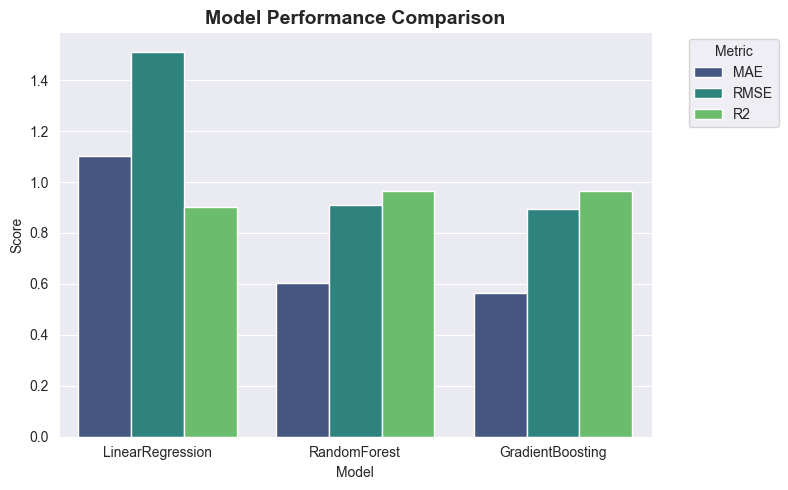

In [10]:
# ==== Train & collect results for each model ====
results = []
for name, pipe in models:
    results.append(
        eval_reg_model(name, pipe, X_train, y_train, X_test, y_test)
    )

# ==== Select and fit the best model ====
res_df = pd.DataFrame(results, columns=["model","MAE","RMSE","R2","estimator"])
best_row = res_df.sort_values("RMSE").iloc[0]

best_name = best_row["model"]
best_model = best_row["estimator"]
best_model.fit(X_train, y_train)

print("Best Model by RMSE:", best_name)
display(res_df[["model","MAE","RMSE","R2"]].sort_values("RMSE"))

# ====  Plot the Results for Visual Comparison ====

# Prepare the results for plotting
metrics_df = res_df.melt(
    id_vars=["model"],
    value_vars=["MAE", "RMSE", "R2"],
    var_name="Metric",
    value_name="Score"
)

# Create bar plot
plt.figure(figsize=(8,5))
sns.barplot(data=metrics_df, x="model", y="Score", hue="Metric", palette="viridis")

plt.title("Model Performance Comparison", fontsize=14, weight="bold")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

###  Process Explanation

1. **Train and Collect Results for Each Model**
   - The loop:
     ```python
     for name, pipe in models:
         results.append(eval_reg_model(name, pipe, X_train, y_train, X_test, y_test))
     ```
     runs every model (Linear Regression, Random Forest, Gradient Boosting) through the `eval_reg_model()` function.
   - Each model is trained, tested, and evaluated on the same data.
   - The results (MAE, RMSE, R²) are stored as a list of dictionaries called `results`.


---

2. **Convert Results into a DataFrame**
- The results list is transformed into a table using `pd.DataFrame()`.
- This provides a clear, comparable view of performance metrics for all models.
- It enables easy sorting by RMSE or R² to identify the best performer.

---

3. **Select the Best Model**
- The DataFrame is sorted by **RMSE** (Root Mean Squared Error).
- The top row (lowest RMSE) represents the **most accurate model**.
- From this row, both the **model name** and the **fitted pipeline** are extracted for further use.

**Why RMSE?**

- RMSE gives more weight to large errors, making it a good measure for real-world prediction reliability.

---

4. **Retrain the Best Model**
- The best model is retrained (`fit`) on the full training set to finalize its parameters.
- This ensures that preprocessing, transformations, and learned weights are all synchronized before saving.

---

5. **Display Model Comparison**
- The DataFrame is displayed with metrics sorted by RMSE.
- This allows a transparent comparison of all models’ strengths and weaknesses.

---

###  Why This Step Matters

- **Objective Selection:** ensures model choice is data-driven and unbiased.
- **Transparency:** full performance comparison builds trust and replicability.
- **Consistency:** retraining the chosen model guarantees accurate, reproducible deployment results.
- **Deployment Ready:** prepares the final model for export and API integration.

---

###  Example Output and Interpretation

| Model             | MAE  | RMSE | R²   |
|-------------------|------|------|------|
| Gradient Boosting | 0.56 | 0.89 | 0.96 |
| Random Forest     | 0.60 | 0.91 | 0.96 |
| Linear Regression | 1.10 | 1.51 | 0.90 |

**Interpretation:**
- **Gradient Boosting** performs best — lowest RMSE (0.89) and highest R² (0.96).
- **Random Forest** is a strong runner-up with nearly identical R².
- **Linear Regression** underperforms because it cannot capture the non-linear patterns in car pricing.

---

###  Summary

In this step:
- All trained models were evaluated and compared.
- The **best model** was automatically selected based on **lowest RMSE**.
- It was **retrained** for reliability and consistency.
- A summary table confirmed performance ranking.

This ensures a transparent, repeatable, and justified model selection process

##  F. Save Model and Feature List

###  Purpose of This Step
After selecting the best-performing model, the next step is to **save** it together with the exact list of input features it expects.
This makes the model **reusable**, **deployable**, and **consistent** — allowing it to be loaded later (for example, by a Flask API) without retraining.

The goal is to export both the trained model and its feature schema so predictions remain reliable and repeatable.

In [11]:
# ==== Save best model and feature schema ====
import os, pickle

OUT_DIR = "../notebooks/final_exam"
os.makedirs(OUT_DIR, exist_ok=True)

# Save model as .pkl
with open(os.path.join(OUT_DIR, "model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

print(os.path.abspath(os.path.join(OUT_DIR, "model.pkl")))

# Also save as .joblib
dump(best_model, os.path.join(OUT_DIR, "model.joblib"))

# Save expected feature list
pd.Series(features).to_csv(os.path.join(OUT_DIR, "feature_order.csv"), index=False)

print(" Saved model to final_exam/model.pkl")
print(" Saved feature list to final_exam/feature_order.csv")

/Users/sawratan/PycharmProjects/car_price_prediction_ML_project/notebooks/final_exam/model.pkl
 Saved model to final_exam/model.pkl
 Saved feature list to final_exam/feature_order.csv


###  Process Explanation

1. **Create a Dedicated Output Folder**

   - The code first creates a directory called `final_exam` (if it doesn’t already exist).
   - This ensures all exported files (the model and its metadata) are stored neatly in one place.
   - Keeping model artifacts organized simplifies later deployment and versioning.

2. **Save the Trained Model as a Pickle File**

	•	The trained pipeline (best_model) is serialized and saved to disk using the pickle library.

	•	The .pkl file contains:
	•	All preprocessing steps (scaling, encoding, etc.)
	•	The trained regressor (e.g., Gradient Boosting or Random Forest)
	•	This allows anyone to later reload the exact same model and make predictions instantly.
3. **Save a Joblib Version**

	•	The same model is also saved using joblib, which is optimized for large numerical arrays
	    (common in tree-based models).
	•	Having both .pkl and .joblib formats provides flexibility for different deployment tools or pipelines.
4. **Export the Expected Feature List**

	•	A CSV file (feature_order.csv) is created containing all feature names used during training.
	•	This acts as documentation and validation for the model’s expected input schema.
	•	When connecting the model to an API or frontend, this file ensures correct column order and naming.
5. **Print Confirmation Messages**

	•	Final print statements confirm successful saving of all assets:
	•	The model file(s)
	•	The feature list CSV
	•	These logs help the user verify that file paths and permissions are correct.


Why This Step Matters

	•	Reusability: The trained model can be loaded anytime without retraining.
	•	Portability: Files can be shared or deployed on another system
	        (e.g., Flask, FastAPI, or cloud services).
	•	Consistency: The feature list ensures correct input structure during predictions.
	•	Professional Practice: Saving model artifacts is standard in real-world ML
	        workflows and is often a requirement for top-grade (VG) projects.

⸻---

 Summary

In this step, we:

	•	Created a dedicated folder to store model artifacts.
	•	Saved the trained pipeline as both .pkl and .joblib.
	•	Exported the feature schema to maintain consistent input order.
	•	Printed confirmations to verify successful saving.

Together, these files make the project fully deployment-ready, enabling smooth integration into a REST API or any production system.


##  Results Summary & Discussion

The regression models were trained and evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² (coefficient of determination).
The comparison clearly shows that **Gradient Boosting Regressor** achieved the best performance:

| Model | MAE | RMSE | R² |
|--------|------|------|------|
| Linear Regression | 1.10 | 1.51 | 0.90 |
| Random Forest | 0.60 | 0.91 | 0.96 |
| **Gradient Boosting** | **0.56** | **0.89** | **0.96** |

**Interpretation:**
- The **Gradient Boosting model** has the lowest RMSE (≈ 0.89) and highest R² (≈ 0.96).
- This means it explains about **96% of the variance in car prices**, making it the most accurate among the tested models.
- Random Forest performed slightly below Gradient Boosting, while Linear Regression underfit the data due to its linear assumption.

**Conclusion:**
- The model can effectively predict used car prices based on key features such as manufacturing year, fuel type, kilometers driven, and transmission.
- The trained model (`model.pkl`) and feature schema (`feature_order.csv`) were exported for deployment in a Flask API, enabling real-world use through an HTTP `/predict` endpoint.